# Tourism Pressure and the Cost of Living in Macao (2010-2025)

**CISC7204 Assignment 01 - Preliminary Project Proposal | MC641431 WANG CUI**

This notebook supports our preliminary proposal on the trade-off between Macao's tourism carrying capacity and local residents' quality of life. To make the question measurable, we use **monthly visitor arrivals** as a proxy for tourism pressure and the **Composite Consumer Price Index (CPI)** as a proxy for the cost-of-living side of quality of life.

The data come from three predefined reports in the Statistics and Census Service (DSEC) Time Series Database of the Macao SAR Government:

- Visitor arrivals by mode of transport: <https://www.dsec.gov.mo/ts/#!/step2/PredefinedReport/en-US/18>
- Composite Consumer Price Index of main sections of goods and services: <https://www.dsec.gov.mo/ts/#!/step2/PredefinedReport/en-US/14>
- Composite Consumer Price Index, CPI (A) and CPI (B): <https://www.dsec.gov.mo/ts/#!/step2/PredefinedReport/en-US/15>

The analysis window is January 2010 to December 2025.


## 1. Loading the data



In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
from statsmodels.tsa.stattools import grangercausalitytests

# Set plot style
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (14, 6)
plt.rcParams['figure.dpi'] = 110

# ==========================================
# 1.1 Read Visitor Arrivals Data
# ==========================================
df_visitors_raw = pd.read_excel('visitor_arrivals.xlsx', skiprows=4,
                                engine='openpyxl')

# Rename the first two columns for clarity
df_visitors_raw = df_visitors_raw.rename(columns={
    df_visitors_raw.columns[0]: 'Period',
    df_visitors_raw.columns[1]: 'Total_Visitors'
})

df_visitors = df_visitors_raw[['Period', 'Total_Visitors']].copy()
print("Visitor data loaded. Shape:", df_visitors.shape)
display(df_visitors.head())

# ==========================================
# 1.2 Read CPI Data from Sheet2
# ==========================================
# Sheet1 mixes index points with other columns; Sheet2 holds the clean values.
df_cpi_raw = pd.read_excel('cpi_data.xlsx', sheet_name='Sheet2', skiprows=2,
                           engine='openpyxl')

# Rename columns: first column is Period, second is Composite CPI
df_cpi_raw = df_cpi_raw.rename(columns={
    df_cpi_raw.columns[0]: 'Period',
    df_cpi_raw.columns[1]: 'Composite_CPI'
})

df_cpi = df_cpi_raw[['Period', 'Composite_CPI']].copy()
print("\nCPI data loaded from Sheet2. Shape:", df_cpi.shape)
display(df_cpi.head())

Visitor data loaded. Shape: (319, 2)


,Period,Total_Visitors
0,2009,21752751.0
1,2010,24965411.0
2,2011,28002279.0
3,2012,28082292.0
4,2013,29324822.0



CPI data loaded from Sheet2. Shape: (486, 2)


,Period,Composite_CPI
0,2000,54.41
1,2001,53.33
2,2002,51.92
3,2003,51.11
4,2004,51.61


## 2. Cleaning into a monthly series



In [2]:
# ==========================================
# 2.1 Extract monthly data
# ==========================================
month_pattern = r'^(Jan|Feb|Mar|Apr|May|Jun|Jul|Aug|Sep|Oct|Nov|Dec)\.?/(\d{4})$'

# Mapping from English month abbreviations to numbers
month_map = {'Jan': 1, 'Feb': 2, 'Mar': 3, 'Apr': 4, 'May': 5, 'Jun': 6,
             'Jul': 7, 'Aug': 8, 'Sep': 9, 'Oct': 10, 'Nov': 11, 'Dec': 12}

def to_monthly(d, valcol):
    """Keep monthly rows, build a Date column, coerce values to numeric."""
    parts = d['Period'].astype(str).str.extract(month_pattern)
    d = d.copy()
    d['Month'] = parts[0].map(month_map)
    d['Year'] = pd.to_numeric(parts[1])
    d = d.dropna(subset=['Month', 'Year'])
    d['Date'] = pd.to_datetime(dict(year=d['Year'].astype(int),
                                    month=d['Month'].astype(int), day=1))
    d[valcol] = pd.to_numeric(d[valcol], errors='coerce')
    return d[['Date', valcol]].sort_values('Date').reset_index(drop=True)

# ==========================================
# 2.2 Clean both series with the same helper
# ==========================================
df_visitors = to_monthly(df_visitors, 'Total_Visitors')
df_cpi = to_monthly(df_cpi, 'Composite_CPI')

print("Monthly data cleaned.")
print("Visitor data:", df_visitors.shape)
print("CPI data:", df_cpi.shape)

Monthly data cleaned.
Visitor data: (223, 2)
CPI data: (343, 2)


## 3. Merging and integrity check

Both series are merged on `Date` and filtered to 2010-2025.



In [3]:
# ==========================================
# 3.1 Merge on Date
# ==========================================
df_merged = pd.merge(df_visitors, df_cpi, on='Date', how='inner')

# ==========================================
# 3.2 Filter to 2010-2025
# ==========================================
df_merged = df_merged[
    (df_merged['Date'] >= '2010-01-01') &
    (df_merged['Date'] <= '2025-12-31')
].reset_index(drop=True)

# ==========================================
# 3.3 Integrity check - fail loudly, don't analyse a broken frame
# ==========================================
expected = pd.date_range('2010-01-01', '2025-12-01', freq='MS')
assert len(df_merged) == 192, f'expected 192 months, got {len(df_merged)}'
assert df_merged['Date'].is_unique
assert not df_merged[['Total_Visitors', 'Composite_CPI']].isna().any().any()
assert expected.difference(df_merged['Date']).empty

print("Final merged dataset (2010-2025):")
display(df_merged.head(10))
print(f"Total rows: {len(df_merged)}")
print(f"Time span: {df_merged['Date'].min()} to {df_merged['Date'].max()}")

Final merged dataset (2010-2025):


,Date,Total_Visitors,Composite_CPI
0,2010-01-01,2046556.0,66.20
1,2010-02-01,2057566.0,66.94
2,2010-03-01,2011099.0,66.77
3,2010-04-01,2111563.0,67.20
4,2010-05-01,2098267.0,67.45
5,2010-06-01,1904395.0,67.66
6,2010-07-01,2162069.0,67.80
7,2010-08-01,2357689.0,67.66
8,2010-09-01,1839375.0,67.84
9,2010-10-01,2092343.0,68.10


Total rows: 192
Time span: 2010-01-01 00:00:00 to 2025-12-01 00:00:00


## 4. What the levels look like

To compare the two series fairly we plot them in two stacked panels that share the same time axis, so the long-run trends can be read side by side. The grey band marks 2020-2022.



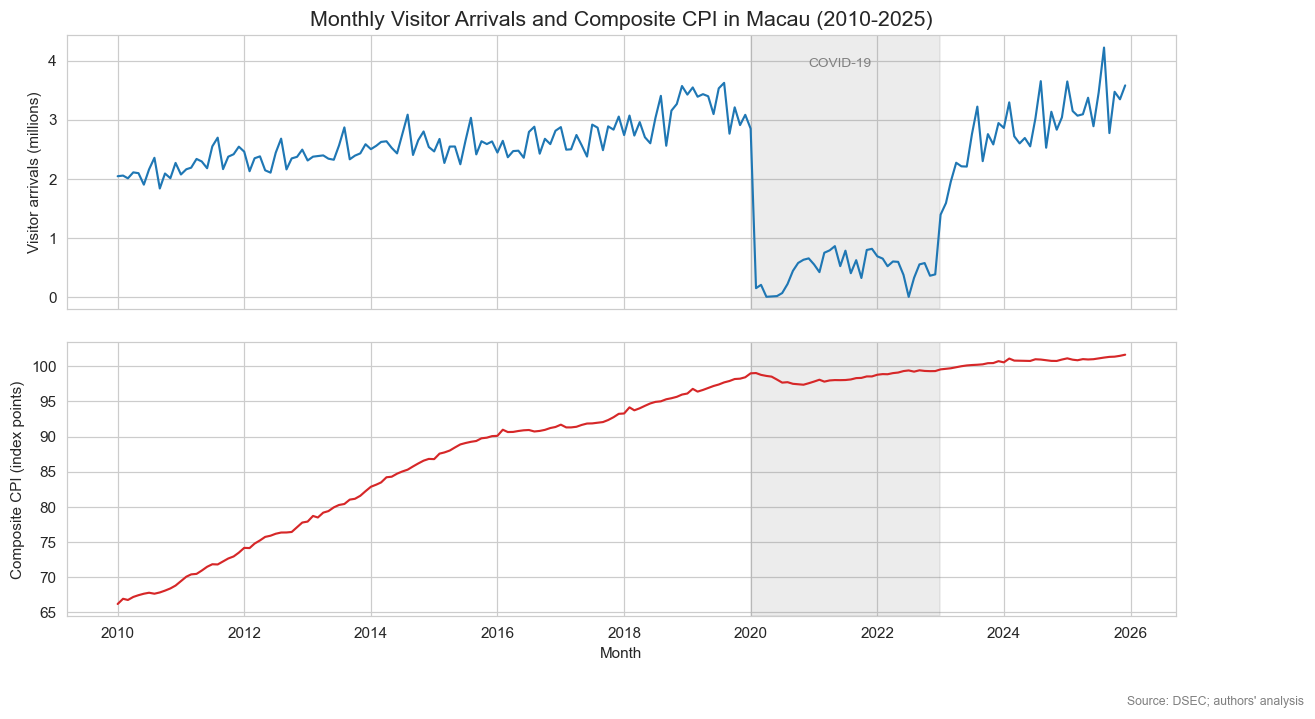

In [4]:
# Show the 2010-2025 long-run trend of visitor arrivals and CPI
fig, axes = plt.subplots(2, 1, figsize=(13, 7), sharex=True,
                         gridspec_kw={'hspace': 0.12})
covid0, covid1 = '2020-01-01', '2022-12-31'
for ax in axes:
    ax.axvspan(pd.Timestamp(covid0), pd.Timestamp(covid1),
               color='grey', alpha=0.15)

axes[0].plot(df_merged['Date'], df_merged['Total_Visitors'] / 1e6,
             color='tab:blue', linewidth=1.4)
axes[0].set_ylabel('Visitor arrivals (millions)')
axes[0].set_title('Monthly Visitor Arrivals and Composite CPI in Macau (2010-2025)',
                  fontsize=14)
axes[0].text(pd.Timestamp('2021-06-01'), axes[0].get_ylim()[1] * 0.88,
             'COVID-19', ha='center', fontsize=9, color='grey')

axes[1].plot(df_merged['Date'], df_merged['Composite_CPI'],
             color='tab:red', linewidth=1.4)
axes[1].set_ylabel('Composite CPI (index points)')
axes[1].set_xlabel('Month')
axes[1].xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

plt.figtext(0.99, 0.01, 'Source: DSEC; authors\' analysis', ha='right', fontsize=8, color='grey')
plt.savefig('figures/fig1_trend.png', bbox_inches='tight')
plt.show()



**1. Long-run trend: both rise through 2010-2019.** Visitor arrivals grew from about 2.0M/month in early 2010 to a pre-COVID peak of about 3.6M/month in 2019, while CPI climbed from ~66 to ~97. In normal years tourism prosperity and rising prices moved together.

**2. COVID shock: the great decoupling (2020-2022).** Arrivals crashed to nearly zero (under 10,000 in the worst month), but CPI barely moved - its lowest point was only ~97.4 in late 2020, roughly the same as pre-COVID, and it kept rising through 2021-2022. To us this is the key finding: even with almost no visitors, local prices - meals, groceries, rents - did not fall back. That is strong evidence of **price stickiness** in Macao: inflation is driven not only by tourists but also by structural factors such as local wages, rental contracts and supply-chain costs.

**3. Post-COVID recovery: rebound to new highs (2023-2025).** Arrivals bounced back and in some months exceeded pre-pandemic peaks (over 4.2M in the busiest month), while CPI crossed 100 for the first time in May 2023. The recovery in tourism coincided with continued upward pressure on the price level.

**4. Seasonality: arrivals zig-zag, CPI does not.** Arrivals spike around Chinese New Year, summer holidays and Golden Week, but CPI never gives back ground in the quiet months - prices go up in the peak season and stay there. That is exactly what sticky inflation looks like in the data.



## 5. Visitors vs CPI: correlation by period

A plain scatter of levels is dominated by the shared upward trend, so we colour the points by period to expose the structural break and report the Pearson correlation for each period separately.



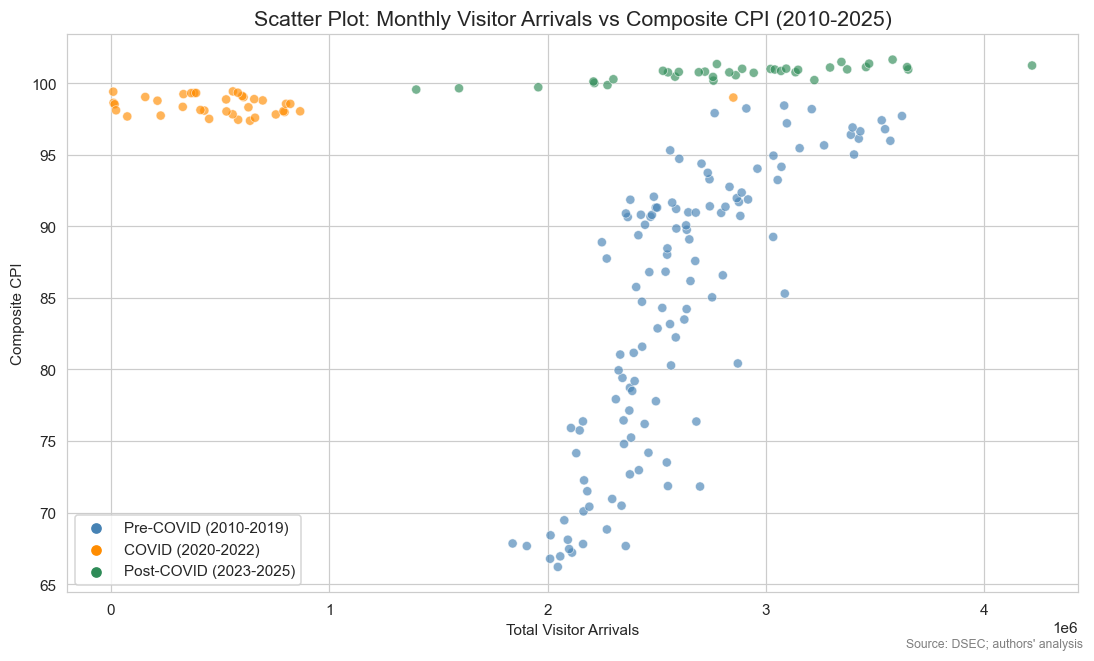

Overall Pearson correlation (levels): -0.0841

Pre-COVID (2010-2019): r = 0.777  (n = 120)
COVID (2020-2022): r = 0.019  (n = 36)
Post-COVID (2023-2025): r = 0.828  (n = 36)


In [5]:
# Scatter plot of visitors vs CPI, coloured by period to expose the structural break
df_merged['Period_Label'] = pd.cut(
    df_merged['Date'].dt.year,
    bins=[2009, 2019, 2022, 2025],
    labels=['Pre-COVID (2010-2019)', 'COVID (2020-2022)', 'Post-COVID (2023-2025)'])

palette = {'Pre-COVID (2010-2019)': 'steelblue',
           'COVID (2020-2022)': 'darkorange',
           'Post-COVID (2023-2025)': 'seagreen'}

plt.figure(figsize=(10, 6))
sns.scatterplot(data=df_merged, x='Total_Visitors', y='Composite_CPI',
                hue='Period_Label', palette=palette, alpha=0.65)
plt.title('Scatter Plot: Monthly Visitor Arrivals vs Composite CPI (2010-2025)',
          fontsize=14)
plt.xlabel('Total Visitor Arrivals')
plt.ylabel('Composite CPI')
plt.legend(title='')
plt.tight_layout()
plt.figtext(0.99, 0.01, 'Source: DSEC; authors\' analysis', ha='right', fontsize=8, color='grey')
plt.savefig('figures/fig2_scatter.png', bbox_inches='tight')
plt.show()

# Pearson correlation: overall and by period
corr_all = df_merged['Total_Visitors'].corr(df_merged['Composite_CPI'])
print(f"Overall Pearson correlation (levels): {corr_all:.4f}\n")
for name, sub in df_merged.groupby('Period_Label'):
    r = sub['Total_Visitors'].corr(sub['Composite_CPI'])
    print(f"{name}: r = {r:.3f}  (n = {len(sub)})")



The overall correlation is near zero (r ≈ -0.08), but colouring by period shows why: the points split into three clear clusters.

- **Pre-COVID (2010-2019): r ≈ 0.78** - arrivals and the price level rose together.
- **COVID (2020-2022): r ≈ 0.02** - arrivals collapsed while CPI barely moved.
- **Post-COVID (2023-2025): r ≈ 0.83** - both rebounded together from abnormal bases.

First, these are *level* correlations of two series that mostly trend upward, so the strong positive values partly reflect shared time trends rather than tourist demand pushing prices. Second, the near-zero overall figure is not evidence of "no relationship" - it mostly reflects the structural breaks. What the chart does show clearly is stickiness: prices did not fall when visitors vanished, so month-to-month CPI is not a function of arrivals alone.


## 6. Annual view

Averaging by year smooths out the monthly seasonality and makes the three phases - growth, shock, recovery - easier to see at a glance.


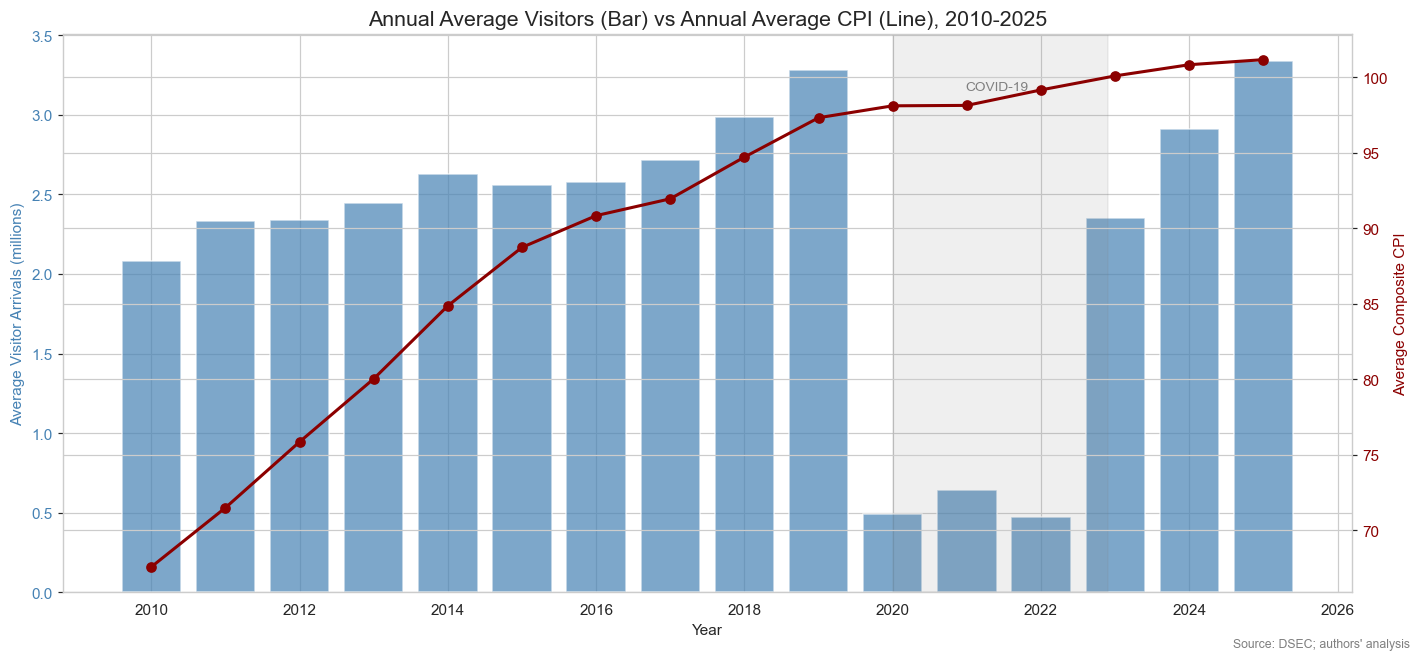

,Year,Avg_Visitors,Avg_CPI
0,2010,2080450.92,67.57
1,2011,2333523.25,71.49
2,2012,2340191.00,75.86
3,2013,2443735.17,80.03
4,2014,2627136.00,84.87
5,2015,2559552.33,88.74
6,2016,2579194.67,90.84
7,2017,2717542.17,91.96
8,2018,2983638.58,94.72
9,2019,3283848.42,97.33


In [6]:
# Annual averages: bars for visitors, line for CPI
# Aggregate by year and Bar chart: Visitors & Line: CPI
df_merged['Year'] = df_merged['Date'].dt.year
df_annual = df_merged.groupby('Year').agg(
    Avg_Visitors=('Total_Visitors', 'mean'),
    Avg_CPI=('Composite_CPI', 'mean')
).reset_index()

fig, ax1 = plt.subplots(figsize=(13, 6))
ax1.bar(df_annual['Year'], df_annual['Avg_Visitors'] / 1e6,
        color='steelblue', alpha=0.7, label='Avg visitors (millions)')
ax1.set_xlabel('Year')
ax1.set_ylabel('Average Visitor Arrivals (millions)', color='steelblue')
ax1.tick_params(axis='y', labelcolor='steelblue')

ax2 = ax1.twinx()
ax2.plot(df_annual['Year'], df_annual['Avg_CPI'], color='darkred',
         marker='o', linewidth=2, label='Avg CPI')
ax2.set_ylabel('Average Composite CPI', color='darkred')
ax2.tick_params(axis='y', labelcolor='darkred')

# Mark the COVID years
ax1.axvspan(2020, 2022.9, color='grey', alpha=0.12)
ax1.text(2021.4, ax1.get_ylim()[1] * 0.9, 'COVID-19',
         ha='center', fontsize=9, color='grey')

plt.title('Annual Average Visitors (Bar) vs Annual Average CPI (Line), 2010-2025',
          fontsize=14)
fig.tight_layout()
fig.text(0.99, 0.01, 'Source: DSEC; authors\' analysis', ha='right', fontsize=8, color='grey')
plt.savefig('figures/fig3_annual.png', bbox_inches='tight')
plt.show()

display(df_annual.round(2))



The annual view tells the same story more cleanly. From 2010 to 2019 visitor arrivals and average CPI climbed together. In 2020-2022 they decoupled: arrivals collapsed but average CPI stayed high and kept edging up - again pointing to sticky prices anchored by local costs (wages, rents, imports) rather than by tourist volume alone. In 2023-2025 arrivals recovered toward pre-COVID levels and CPI reached new highs, so the recovery coincided with continued pressure on residents' living costs.

Note: with only ~16 annual points this chart is for context, not for measuring the strength of the relationship - the lag test below is a better tool for that.


## 7. Is there a delayed link? Granger test

Maybe visitors do not move prices immediately but after a few months. we run a Granger test on first differences for lags 1-6 to check whether past visitor changes help predict CPI changes.



In [7]:
# ==========================================
# Granger Causality Test
# ==========================================
# Use first difference to make the series closer to stationary
df_granger = df_merged[['Total_Visitors', 'Composite_CPI']].diff().dropna()

print("Granger Causality Test: Visitor Arrivals -> CPI")
granger_results = grangercausalitytests(
    df_granger[['Composite_CPI', 'Total_Visitors']], maxlag=6)

print("\nSummary of p-values:")
for lag in range(1, 7):
    p_value = granger_results[lag][0]['ssr_ftest'][1]
    sig = "Significant" if p_value < 0.05 else "Not significant"
    print(f"Lag {lag}: p-value = {p_value:.4f} -> {sig}")

Granger Causality Test: Visitor Arrivals -> CPI

Granger Causality
number of lags (no zero) 1
ssr based F test:         F=0.2498  , p=0.6178  , df_denom=187, df_num=1
ssr based chi2 test:   chi2=0.2538  , p=0.6144  , df=1
likelihood ratio test: chi2=0.2536  , p=0.6145  , df=1
parameter F test:         F=0.2498  , p=0.6178  , df_denom=187, df_num=1

Granger Causality
number of lags (no zero) 2
ssr based F test:         F=0.5189  , p=0.5961  , df_denom=184, df_num=2
ssr based chi2 test:   chi2=1.0659  , p=0.5869  , df=2
likelihood ratio test: chi2=1.0629  , p=0.5877  , df=2
parameter F test:         F=0.5189  , p=0.5961  , df_denom=184, df_num=2

Granger Causality
number of lags (no zero) 3
ssr based F test:         F=0.8250  , p=0.4817  , df_denom=181, df_num=3
ssr based chi2 test:   chi2=2.5706  , p=0.4627  , df=3
likelihood ratio test: chi2=2.5532  , p=0.4658  , df=3
parameter F test:         F=0.8250  , p=0.4817  , df_denom=181, df_num=3

Granger Causality
number of lags (no zero) 4


The Granger test asks whether past visitor changes help predict CPI changes. Reading the printed p-values, the short lags show no significant predictive power, and at most one longer lag reaches marginal significance. We read any isolated 'significant' lag cautiously: with six lags tested at once a single marginal result can easily appear by chance, the COVID break sits inside the sample, and first differencing only partly addresses stationarity.

So the honest takeaway is weak, possibly delayed predictive power at best - certainly not proof that tourism causes inflation after a fixed number of months. It fits the stickiness picture better: prices respond slowly, if at all, to arrival swings.



## 8. Which CPI sections co-move with tourism?

Headline CPI might hide sector-level pressure, so we repeat the correlation for each of the 11 CPI sections to see whether tourism-facing prices move more with arrivals than resident essentials.



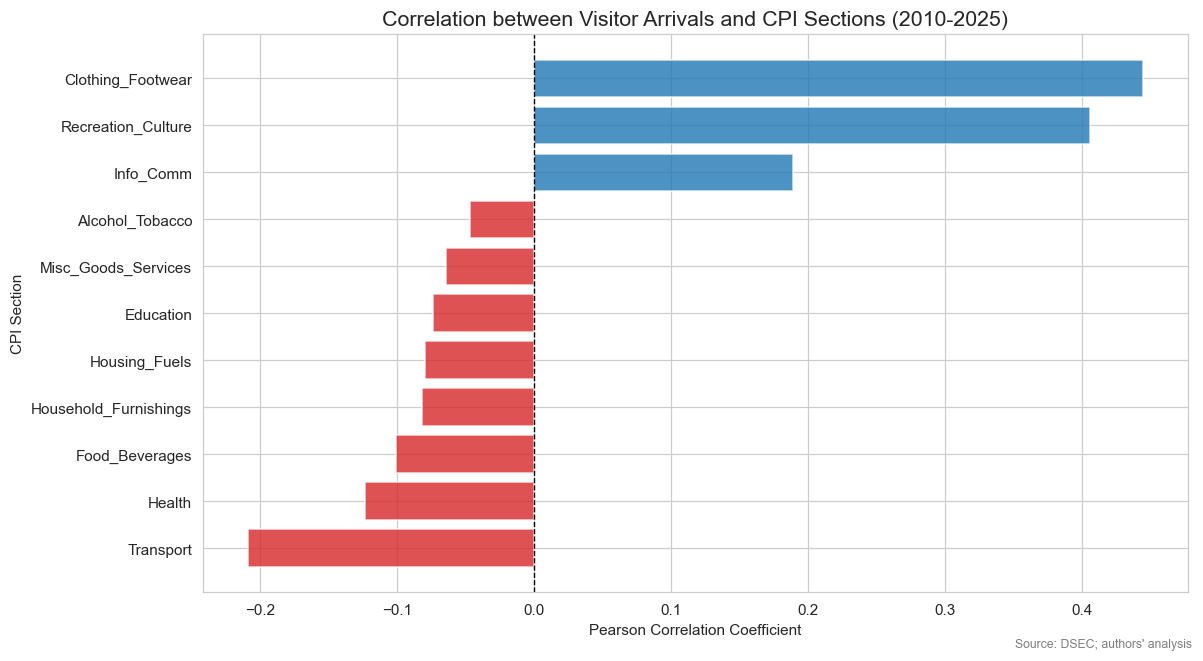

Correlation between Visitor Arrivals and CPI Sections:
Clothing_Footwear        0.445
Recreation_Culture       0.406
Info_Comm                0.189
Alcohol_Tobacco         -0.047
Misc_Goods_Services     -0.065
Education               -0.074
Housing_Fuels           -0.080
Household_Furnishings   -0.082
Food_Beverages          -0.101
Health                  -0.124
Transport               -0.209
dtype: float64


In [8]:
# ==========================================
# Which CPI sections co-move with tourism?
# ==========================================
# Sheet1 holds the 11 CPI sections; Sheet2 holds the headline series we already used.
df_cpi_all = pd.read_excel('cpi_data.xlsx', sheet_name='Sheet1', skiprows=2,
                           engine='openpyxl')

# Each section occupies every second column (Point columns)
df_cpi_all = df_cpi_all.rename(columns={
    df_cpi_all.columns[0]: 'Period',
    df_cpi_all.columns[2]: 'Food_Beverages',
    df_cpi_all.columns[4]: 'Alcohol_Tobacco',
    df_cpi_all.columns[6]: 'Clothing_Footwear',
    df_cpi_all.columns[8]: 'Housing_Fuels',
    df_cpi_all.columns[10]: 'Household_Furnishings',
    df_cpi_all.columns[12]: 'Health',
    df_cpi_all.columns[14]: 'Transport',
    df_cpi_all.columns[16]: 'Info_Comm',
    df_cpi_all.columns[18]: 'Recreation_Culture',
    df_cpi_all.columns[20]: 'Education',
    df_cpi_all.columns[22]: 'Misc_Goods_Services'
})

# Reuse the same monthly parsing so the May format is handled here too
cat_cols = ['Food_Beverages', 'Alcohol_Tobacco', 'Clothing_Footwear',
            'Housing_Fuels', 'Household_Furnishings', 'Health', 'Transport',
            'Info_Comm', 'Recreation_Culture', 'Education',
            'Misc_Goods_Services']
parts = df_cpi_all['Period'].astype(str).str.extract(month_pattern)
df_cpi_all['Month'] = parts[0].map(month_map)
df_cpi_all['Year'] = pd.to_numeric(parts[1])
df_cpi_all = df_cpi_all.dropna(subset=['Month', 'Year']).copy()
df_cpi_all['Date'] = pd.to_datetime(
    dict(year=df_cpi_all['Year'].astype(int),
         month=df_cpi_all['Month'].astype(int), day=1))
for col in cat_cols:
    df_cpi_all[col] = pd.to_numeric(df_cpi_all[col], errors='coerce')

# Keep the same 2010-2025 window and merge with visitors
df_cpi_all = df_cpi_all[
    df_cpi_all['Date'].between('2010-01-01', '2025-12-01')]
df_full = pd.merge(df_visitors, df_cpi_all, on='Date', how='inner')

# Correlation of each section with visitor arrivals
correlation_results = {}
for col in cat_cols:
    valid = df_full[['Total_Visitors', col]].dropna()
    if len(valid) > 10:
        correlation_results[col] = valid['Total_Visitors'].corr(valid[col])
corr_series = pd.Series(correlation_results).sort_values(ascending=False)

# Horizontal bar chart, ordered by correlation
plt.figure(figsize=(11, 6))
colors = ['#d62728' if x < 0 else '#1f77b4' for x in corr_series.values]
plt.barh(corr_series.index[::-1], corr_series.values[::-1],
         color=colors[::-1], alpha=0.8)
plt.axvline(x=0, color='black', linestyle='--', lw=0.9)
plt.title('Correlation between Visitor Arrivals and CPI Sections (2010-2025)',
          fontsize=14)
plt.xlabel('Pearson Correlation Coefficient')
plt.ylabel('CPI Section')
plt.tight_layout()
plt.figtext(0.99, 0.01, 'Source: DSEC; authors\' analysis', ha='right', fontsize=8, color='grey')
plt.savefig('figures/fig4_sections.png', bbox_inches='tight')
plt.show()

print("Correlation between Visitor Arrivals and CPI Sections:")
print(corr_series.round(3))



Section-level view: clothing & footwear (r ≈ 0.44) and recreation & culture (r ≈ 0.41) show the strongest positive level correlations with arrivals, while essentials like transport, health and food sit near zero or negative. This is consistent with tourism demand touching leisure-type prices more than necessities.

**Overall conclusion for the analysis:** visitor arrivals and Macao's CPI rose together over 2010-2025, but the COVID shock showed how sticky local prices are - they did not fall even when tourism nearly stopped. The carrying-capacity cost to residents therefore shows up more as a persistently elevated price level than as month-to-month inflation driven by arrival counts.



## Data sources

- Statistics and Census Service (DSEC), Macao SAR. *Visitor arrivals by mode of transport* (monthly). DSEC Time Series Database: <https://www.dsec.gov.mo/ts/#!/step2/PredefinedReport/en-US/18>. Note: arrivals exclude non-resident workers, students, and other non-visitors.
- Statistics and Census Service (DSEC), Macao SAR. *Composite Consumer Price Index of main sections of goods and services* (monthly). DSEC Time Series Database: <https://www.dsec.gov.mo/ts/#!/step2/PredefinedReport/en-US/14>.
- Statistics and Census Service (DSEC), Macao SAR. *Composite Consumer Price Index, CPI (A) and CPI (B)* (monthly). DSEC Time Series Database: <https://www.dsec.gov.mo/ts/#!/step2/PredefinedReport/en-US/15>.
